In [10]:
import tensorflow as tf
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.manifold import trustworthiness
from scipy.spatial import distance_matrix, procrustes
from scipy.optimize import linear_sum_assignment

# ==========================================
# 1. 数据加载 (DICHASUS 005x)
# ==========================================
DATASET_PATTERN = "dichasus/dichasus-005*.tfrecords" 
ANTENNA_COUNT = 32

def load_dataset_005x():
    files = glob.glob(DATASET_PATTERN)
    if not files: raise ValueError("未找到数据文件！请检查路径 dichasus/ 下是否有文件")
    
    def parse(proto):
        desc = {
            "csi": tf.io.FixedLenFeature([], tf.string),
            "pos-lidar": tf.io.FixedLenFeature([], tf.string),
            "time": tf.io.FixedLenFeature([], tf.float32)
        }
        rec = tf.io.parse_single_example(proto, desc)
        csi = tf.ensure_shape(tf.io.parse_tensor(rec["csi"], out_type=tf.float32), (32, 1024, 2))
        csi = tf.complex(csi[:, :, 0], csi[:, :, 1])
        pos = tf.ensure_shape(tf.io.parse_tensor(rec["pos-lidar"], out_type=tf.float64), (2))
        time = tf.ensure_shape(rec["time"], ())
        return csi, pos, time

    def preprocess(csi, pos, time):
        # 频域 -> 时域 -> 截取中心 32 taps
        csi = tf.signal.fftshift(csi, axes=1)
        csi_t = tf.signal.ifft(csi)
        csi_t = tf.signal.fftshift(csi_t, axes=1)
        csi_cut = csi_t[:, 512-16:512+16]
        
        # --- 修正点 ---
        # 删除手动的归一化除法，避免除以 0 或类型报错
        # csi_cut = csi_cut / ... (删除这几行)
        
        return csi_cut, pos, time

    print("正在加载数据...")
    ds = tf.data.TFRecordDataset(files).map(parse).map(preprocess)
    iterator = list(ds.as_numpy_iterator())
    
    csi = np.array([x[0] for x in iterator])
    pos = np.array([x[1] for x in iterator])
    time = np.array([x[2] for x in iterator])
    print(f"加载完成: CSI {csi.shape}, Pos {pos.shape}")
    return csi, pos, time

# 重新运行数据加载
csi_data, pos_data, time_data = load_dataset_005x()


正在加载数据...
加载完成: CSI (21160, 32, 32), Pos (21160, 2)


2026-01-29 09:10:22.013237: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:
# ==========================================
# 2. ResNet 模型 (输出 2D 坐标)
# ==========================================
class ResNetBlock(tf.keras.layers.Layer):
    def __init__(self, units, dropout=0.2):
        super().__init__()
        self.units = units
        
        # 主路径层
        self.dense1 = tf.keras.layers.Dense(units)
        self.bn1 = tf.keras.layers.BatchNormalization()
        self.act1 = tf.keras.layers.Activation('relu')
        self.dropout = tf.keras.layers.Dropout(dropout)
        
        self.dense2 = tf.keras.layers.Dense(units)
        self.bn2 = tf.keras.layers.BatchNormalization()
        
        # 快捷路径投影层 (Projection Shortcut)
        # 只有当维度不匹配时才会用到它
        self.projector = tf.keras.layers.Dense(units)
        
        self.add_layer = tf.keras.layers.Add()
        self.act2 = tf.keras.layers.Activation('relu')

    def call(self, inputs):
        # 1. 主路径计算 (F(x))
        x = self.dense1(inputs)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.dropout(x)
        
        x = self.dense2(x)
        x = self.bn2(x)

        # 2. 快捷路径处理 (x)
        shortcut = inputs
        # [关键修复]：检查输入维度是否等于目标维度
        if inputs.shape[-1] != self.units:
            # 如果不相等 (例如输入512，目标256)，则通过一个 Dense 层投影过去
            shortcut = self.projector(inputs)

        # 3. 残差连接 (F(x) + x)
        x = self.add_layer([shortcut, x])
        return self.act2(x)

def build_smooth_model(input_shape):
    inputs = tf.keras.Input(shape=input_shape, dtype=tf.complex64)
    
    # ... (前面的预处理和骨干保持不变) ...
    # 重新写一遍前半部分以防万一
    x = tf.keras.layers.Flatten()(inputs)
    def split_feat(c):
        return tf.concat([tf.math.abs(c), tf.math.real(c), tf.math.imag(c)], axis=-1)
    x = tf.keras.layers.Lambda(split_feat)(x)
    x = tf.keras.layers.BatchNormalization()(x) # 这一层BN至关重要，防止初始梯度爆炸
    
    x = tf.keras.layers.Dense(512, activation='relu')(x)
    x = ResNetBlock(512)(x)
    x = ResNetBlock(256)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    
    # --- 修正点 ---
    # 移除 activation='tanh'，改用默认的 linear (即不写 activation)
    # 这样坐标可以是 [10, 20] 这种大数值，不再受限
    outputs = tf.keras.layers.Dense(2, name='chart')(x)
    
    return tf.keras.Model(inputs=inputs, outputs=outputs)

model = build_smooth_model(csi_data.shape[1:])

/workspace/anaconda/envs/py39/lib/python3.9/site-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'res_net_block_8', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


In [12]:


# ==========================================
# 3. 混合平滑 Loss (Triplet + Smoothness)
# ==========================================
def smooth_triplet_loss(y_true, y_pred):
    """
    y_pred: [Anchor, Positive, Negative] 的拼接
    """
    # 1. 拆分
    dim = 2 # 2D 坐标
    anchor = y_pred[:, 0:dim]
    positive = y_pred[:, dim:2*dim] # 正例 (时间紧邻)
    negative = y_pred[:, 2*dim:3*dim] # 负例 (时间远邻)
    
    # 2. Triplet Loss (拉开正负差距)
    d_pos = tf.reduce_sum(tf.square(anchor - positive), axis=1)
    d_neg = tf.reduce_sum(tf.square(anchor - negative), axis=1)
    margin = 1.0
    loss_triplet = tf.maximum(d_pos - d_neg + margin, 0.0)
    
    # 3. Smoothness Loss (强力压缩正例距离)
    # 强制 anchor 和 positive (它们在时间上很近) 在空间上也必须几乎重合
    # 这能消除 "散乱"
    loss_smooth = d_pos 
    
    # 总 Loss: 主要是 Triplet，辅以 Smoothness
    return tf.reduce_mean(loss_triplet + 0.5 * loss_smooth)

# ==========================================
# 4. 生成器 (严格时序采样)
# ==========================================
def strict_time_generator(csi, time, batch_size=128):
    n = len(csi)
    # 严格的参数
    POS_WINDOW = 1.0   # 正例：1秒内 (非常近，保证平滑)
    NEG_MARGIN = 15.0  # 负例：15秒外 (保证推得够远)
    
    while True:
        anchor_idx = np.random.randint(0, n, batch_size)
        anchor_time = time[anchor_idx]
        
        pos_idx = []
        neg_idx = []
        
        for i in range(batch_size):
            a_idx = anchor_idx[i]
            t_a = anchor_time[i]
            
            # 找正例 (Local) - 优先选最近的
            # 假设数据局部有序，只搜附近
            search_range = slice(max(0, a_idx-200), min(n, a_idx+200))
            local_t = time[search_range]
            valid = np.where(np.abs(local_t - t_a) < POS_WINDOW)[0]
            
            if len(valid) > 0:
                p_idx = search_range.start + np.random.choice(valid)
            else:
                p_idx = a_idx
            pos_idx.append(p_idx)
            
            # 找负例 (Global)
            while True:
                n_idx = np.random.randint(0, n)
                if np.abs(time[n_idx] - t_a) > NEG_MARGIN:
                    break
            neg_idx.append(n_idx)
            
        ba = csi[anchor_idx].astype(np.complex64)
        bp = csi[pos_idx].astype(np.complex64)
        bn = csi[neg_idx].astype(np.complex64)
        
        # 简单增强: 旋转
        rot = np.exp(1j * np.random.uniform(0, 2*np.pi))
        yield (ba*rot, bp*rot, bn*rot), np.zeros(batch_size)





In [13]:
# ==========================================
# 5. 训练
# ==========================================
# 构建三路模型
in_a = tf.keras.Input(shape=csi_data.shape[1:], dtype=tf.complex64)
in_p = tf.keras.Input(shape=csi_data.shape[1:], dtype=tf.complex64)
in_n = tf.keras.Input(shape=csi_data.shape[1:], dtype=tf.complex64)

out_a = model(in_a)
out_p = model(in_p)
out_n = model(in_n)

concat = tf.keras.layers.Concatenate(axis=1)([out_a, out_p, out_n])
trainer = tf.keras.Model(inputs=[in_a, in_p, in_n], outputs=concat)

trainer.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=smooth_triplet_loss)

ds = tf.data.Dataset.from_generator(
    lambda: strict_time_generator(csi_data, time_data),
    output_signature=(
        (tf.TensorSpec((None,32,32), tf.complex64), tf.TensorSpec((None,32,32), tf.complex64), tf.TensorSpec((None,32,32), tf.complex64)),
        tf.TensorSpec((None,), tf.float32)
    )
)

print("开始训练 (Smooth Triplet)...")
trainer.fit(ds, steps_per_epoch=200, epochs=40, verbose=1)

开始训练 (Smooth Triplet)...
Epoch 1/40
  9/200 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 2.1358

2026-01-29 09:10:44.589991: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_reduce_select_fusion_5', 8 bytes spill stores, 8 bytes spill loads



200/200 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - loss: 0.7588
Epoch 2/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2174
Epoch 3/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1713
Epoch 4/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1551
Epoch 5/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1413
Epoch 6/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1335
Epoch 7/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1230
Epoch 8/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1133
Epoch 9/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1104
Epoch 10/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1053
Epoch 11/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1019
Epoch 12/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1020
Epoch 13/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0950
Epoch 14/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0962
Epoch 15/40
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.091

正在预测坐标...
83/83 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step

>>> 最终 Kruskal Stress (KS): 0.3998
效果良好 (Good)


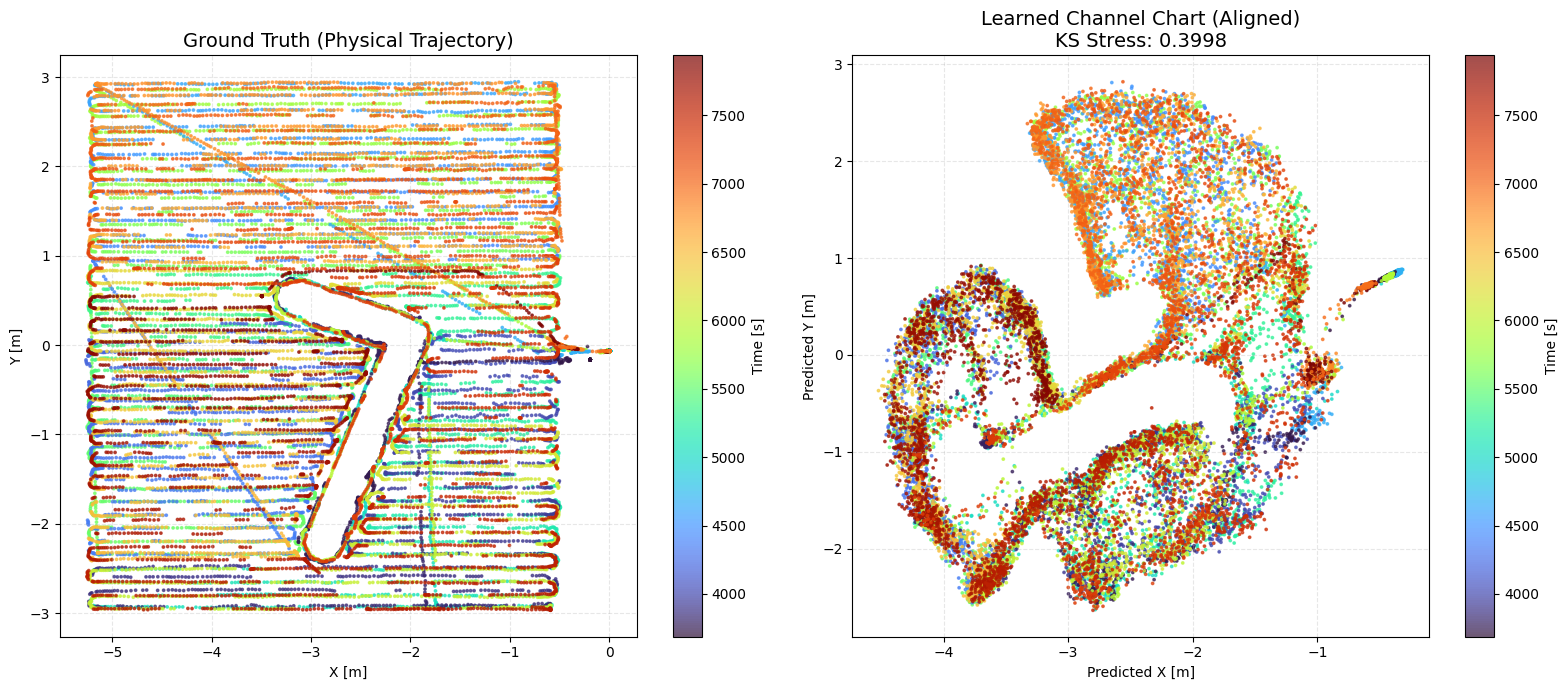

In [14]:
# ==========================================
# 6. 对比可视化与评估
# ==========================================
print("正在预测坐标...")
pred_coords = model.predict(csi_data.astype(np.complex64), batch_size=256)

# --- 对齐 (Alignment) ---
# 使用 Ridge 回归进行 仿射变换 (平移+旋转+缩放)
# 将预测坐标映射到真实坐标系，以便直观对比
reg = Ridge(alpha=0.1) # 线性回归
# 随机采样一半用于训练对齐参数
X_train, X_test, y_train, y_test = train_test_split(pred_coords, pos_data, test_size=0.5, random_state=42)
reg.fit(X_train, y_train)

# 对所有预测点进行变换
aligned_pred = reg.predict(pred_coords)

# --- 计算 KS 指标 ---
# 采样 1000 个点计算，否则内存溢出
idx_sample = np.random.choice(len(pos_data), 1000, replace=False)
gt_sample = pos_data[idx_sample]
pr_sample = aligned_pred[idx_sample]

d_gt = distance_matrix(gt_sample, gt_sample)
d_pr = distance_matrix(pr_sample, pr_sample)
# 归一化以比较结构
d_gt /= np.max(d_gt)
d_pr /= np.max(d_pr)
# Stress 计算
stress = np.sqrt(np.sum((d_gt - d_pr)**2) / np.sum(d_gt**2))

print(f"\n>>> 最终 Kruskal Stress (KS): {stress:.4f}")
if stress < 0.2: print("效果优秀 (Excellent)")
elif stress < 0.4: print("效果良好 (Good)")
else: print("效果一般 (Fair)")

# --- 绘图 ---
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# 图1: 真实坐标 (Ground Truth)
sc1 = ax[0].scatter(pos_data[:, 0], pos_data[:, 1], c=time_data, cmap='turbo', s=3, alpha=0.7)
ax[0].set_title("Ground Truth (Physical Trajectory)", fontsize=14)
ax[0].set_xlabel("X [m]")
ax[0].set_ylabel("Y [m]")
ax[0].grid(True, linestyle='--', alpha=0.3)
plt.colorbar(sc1, ax=ax[0], label="Time [s]")

# 图2: 映射后的学习坐标 (Learned Chart)
sc2 = ax[1].scatter(aligned_pred[:, 0], aligned_pred[:, 1], c=time_data, cmap='turbo', s=3, alpha=0.7)
ax[1].set_title(f"Learned Channel Chart (Aligned)\nKS Stress: {stress:.4f}", fontsize=14)
ax[1].set_xlabel("Predicted X [m]")
ax[1].set_ylabel("Predicted Y [m]")
ax[1].grid(True, linestyle='--', alpha=0.3)
plt.colorbar(sc2, ax=ax[1], label="Time [s]")

plt.tight_layout()
plt.show()